<a href="https://colab.research.google.com/github/Vishnum369/python-case-study/blob/main/unsupervised_fish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler

In [ ]:
#loading dataset
from google.colab import files
uploaded = files.upload()

Saving fish.csv to fish.csv


In [ ]:
df_fish = pd.read_csv('/content/fish.csv')
df_fish.head()

,Bream,242.0,23.2,25.4,30.0,38.4,13.4
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2


In [ ]:
df_fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Bream   84 non-null     object 
 1   242.0   84 non-null     float64
 2   23.2    84 non-null     float64
 3   25.4    84 non-null     float64
 4   30.0    84 non-null     float64
 5   38.4    84 non-null     float64
 6   13.4    84 non-null     float64
dtypes: float64(6), object(1)
memory usage: 4.7+ KB


In [ ]:
#separate the first column for later verification
fish_names = df_fish.iloc[:,0]
x=df_fish.iloc[:,1:] #ignore first column for training

In [ ]:
#scale the features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [ ]:
#build k-mean model
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)
df_fish['cluster'] = kmeans.fit_predict(x_scaled)

In [ ]:
#compare clusters with fish names
verification = pd.DataFrame({'fish':fish_names,'cluster':df_fish['cluster']})
print("\ncluster verification:\n",verification)


cluster verification:
      fish  cluster
0   Bream        2
1   Bream        2
2   Bream        2
3   Bream        2
4   Bream        2
..    ...      ...
79   Pike        0
80   Pike        0
81   Pike        0
82   Pike        0
83   Pike        0

[84 rows x 2 columns]


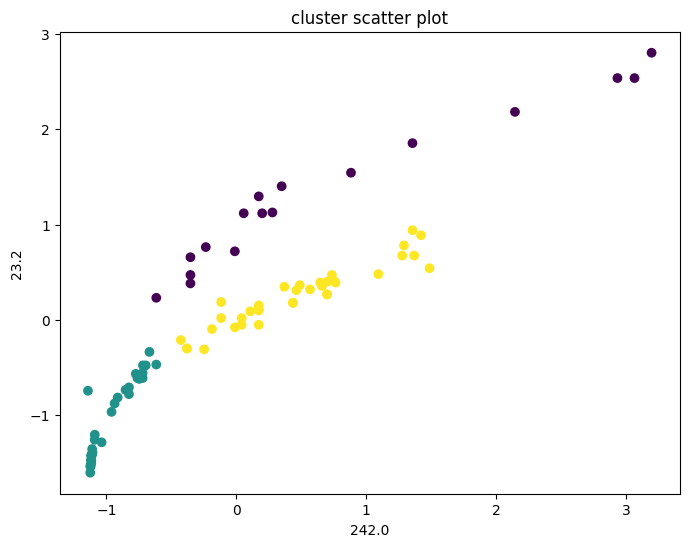

In [ ]:
#plot cluster scatter plot using first two features
plt.figure(figsize=(8,6))
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=df_fish['cluster'])
plt.xlabel(x.columns[0])
plt.ylabel(x.columns[1])
plt.title('cluster scatter plot')
plt.show()

In [ ]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster

In [ ]:
ag_cluster = linkage(x,method='ward') #ward,singlee,centroid
#linkage matrix i.e, agglomerative cluster model

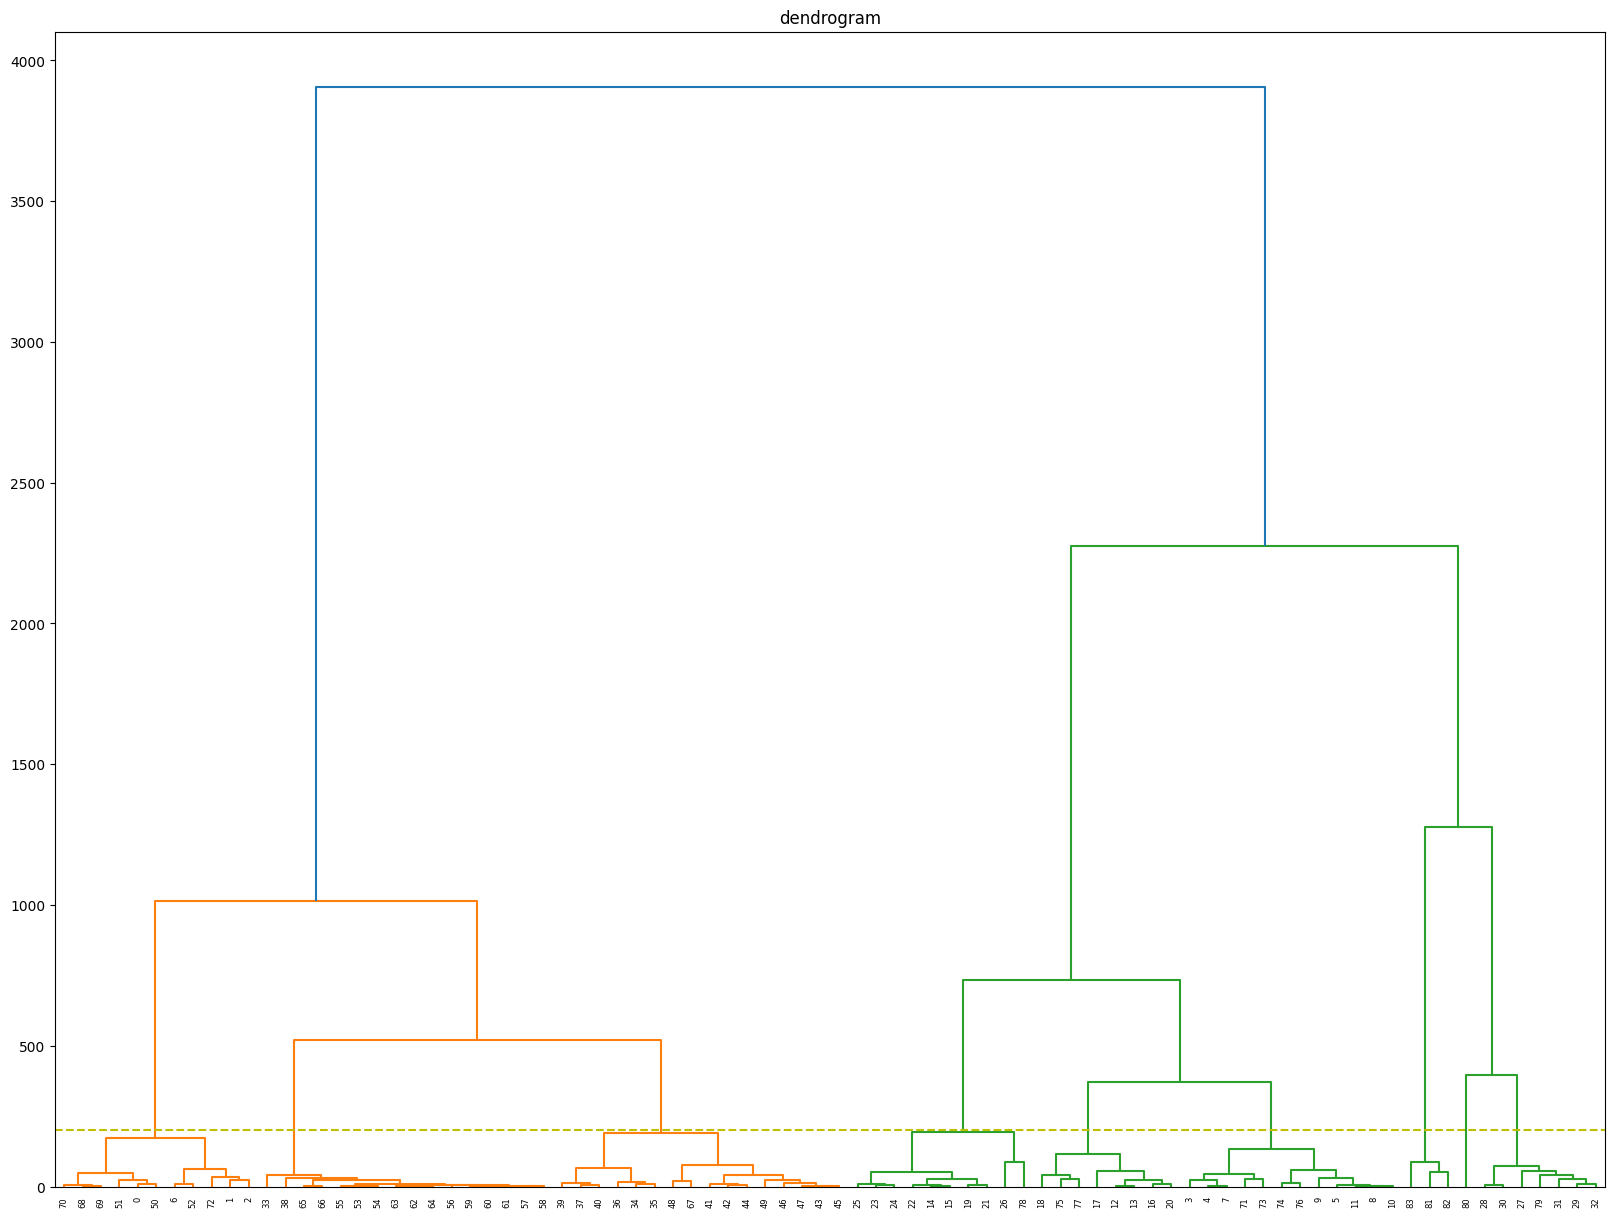

In [ ]:
plt.figure(figsize=(20,15))
dendrogram(ag_cluster)
plt.axhline(y=200,color='y',linestyle='--')
plt.title('dendrogram')
plt.show()

In [ ]:
cluster_labels = fcluster(ag_cluster,t=200,criterion='distance')
cluster_labels

array([1, 1, 1, 6, 6, 6, 1, 6, 6, 6, 6, 6, 5, 5, 4, 4, 5, 5, 5, 4, 5, 4,
       4, 4, 4, 4, 4, 8, 8, 8, 8, 8, 8, 2, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 3, 1, 1, 1, 6, 1, 6, 6, 5, 6, 5, 4, 8, 9, 7, 7, 7], dtype=int32)

In [ ]:
df_fish['cluster_Agglomerative']=cluster_labels
df_fish.head()

,Bream,242.0,23.2,25.4,30.0,38.4,13.4,cluster,cluster_Agglomerative
0,Bream,290.0,24.0,26.3,31.2,40.0,13.8,2,1
1,Bream,340.0,23.9,26.5,31.1,39.8,15.1,2,1
2,Bream,363.0,26.3,29.0,33.5,38.0,13.3,2,1
3,Bream,430.0,26.5,29.0,34.0,36.6,15.1,2,6
4,Bream,450.0,26.8,29.7,34.7,39.2,14.2,2,6


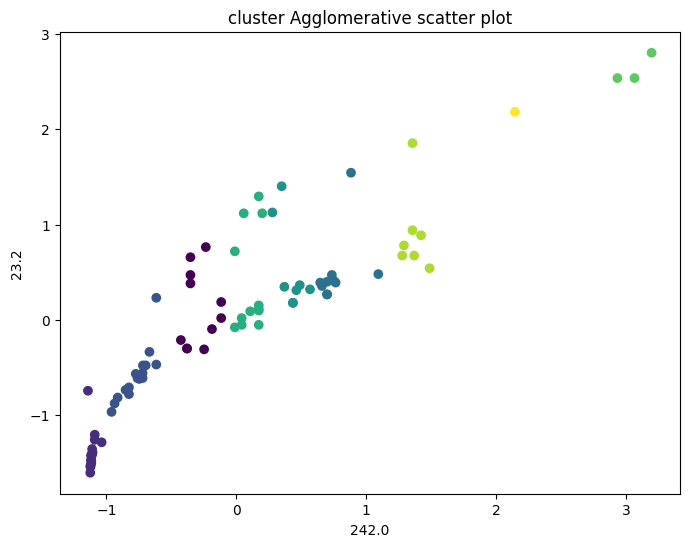

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=df_fish['cluster_Agglomerative'])
plt.xlabel(x.columns[0])
plt.ylabel(x.columns[1])
plt.title('cluster Agglomerative scatter plot')
plt.show()

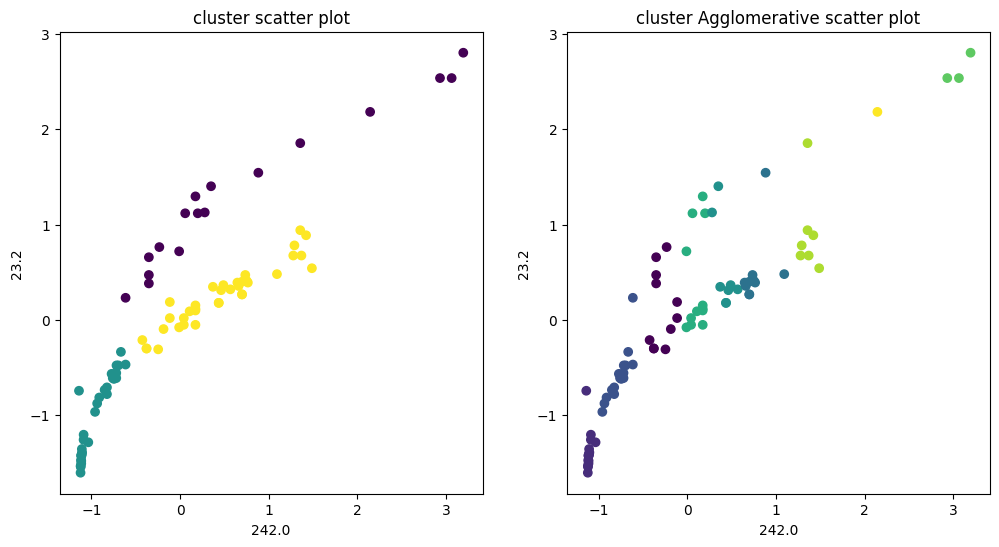

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=df_fish['cluster'])
plt.xlabel(x.columns[0])
plt.ylabel(x.columns[1])
plt.title('cluster scatter plot')
plt.subplot(1,2,2)
plt.scatter(x_scaled[:,0],x_scaled[:,1],c=df_fish['cluster_Agglomerative'])
plt.xlabel(x.columns[0])
plt.ylabel(x.columns[1])
plt.title('cluster Agglomerative scatter plot')
plt.show()